In [125]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

years = [2014, 2016]
all_rows = []
headers = []
headers_req = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}

for year in years:
    url = f"https://en.wikipedia.org/wiki/List_of_exoplanets_discovered_in_{year}"
    response = requests.get(url, headers=headers_req)
    
    # Initialize the parsing engine
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Locate all table nodes in the DOM
    tables = soup.find_all('table')
    
    # Isolate the target node by counting child row nodes
    target_table = max(tables, key=lambda t: len(t.find_all('tr')))
    
    rows = target_table.find_all('tr')
    
    # Extract headers only once
    if not headers:
        header_cells = rows[0].find_all(['th', 'td'])
        headers = [cell.text.strip().replace('\n', ' ') for cell in header_cells]
        headers.append('Discovery_Year')
        
    # Traverse data rows
    for row in rows[1:]:
        cells = row.find_all(['td', 'th'])
        row_data = [cell.text.strip().replace('\n', '') for cell in cells]
        
        # Filter malformed rows utilizing colspan/rowspan by checking length
        if len(row_data) == len(headers) - 1:
            row_data.append(year)
            all_rows.append(row_data)

# Persist the clean data structure to a DataFrame and save
df = pd.DataFrame(all_rows, columns=headers)
df.to_csv('data_exoplanets.csv', index=False)
print("success")

success


Data Undertanding

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("data_exoplanets.csv")
data.head()

,Name,Mass (MJ),Radius (RJ),Period (days),Semi-major axis (AU),Temp. (K)[1],Discovery method,Distance (ly),Host star mass (M☉),Host star temp. (K),Remarks,Discovery_Year
0,BD-11 4672 b,0.53,NaN,1667,2.28,NaN,radial vel.,89,0.57,4475,[2],2014
1,Beta Cancri b,7.8,NaN,605.2,1.7,NaN,radial vel.,290.4,1.7,4092.1,[3],2014
2,Beta Ursae Minoris b,6.1,NaN,522.3,1.4,NaN,radial vel.,126.5,1.4,4126,[3],2014
3,COROT-22b,0.038,0.435,9.75598,0.092,885,transit,1930,1.1,5939,[4],2014
4,COROT-24b,0.018,0.33,5.1134,0.056,1070,transit,2000,0.91,4950,[5],2014


In [127]:
data.describe()

,Discovery_Year
count,2367.000000
mean,2015.265737
std,0.964249
min,2014.000000
25%,2014.000000
50%,2016.000000
75%,2016.000000
max,2016.000000


In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name                  2367 non-null   object
 1   Mass (MJ)             299 non-null    object
 2   Radius (RJ)           2240 non-null   object
 3   Period (days)         2348 non-null   object
 4   Semi-major axis (AU)  1018 non-null   object
 5   Temp. (K)[1]          104 non-null    object
 6   Discovery method      2367 non-null   object
 7   Distance (ly)         2291 non-null   object
 8   Host star mass (M☉)   2101 non-null   object
 9   Host star temp. (K)   2340 non-null   object
 10  Remarks               2367 non-null   object
 11  Discovery_Year        2367 non-null   int64 
dtypes: int64(1), object(11)
memory usage: 222.0+ KB


disini tipe data setiap fiturnya "object" kecuali discovery_year, sehingga tidak bisa di lakukan analisis, sehingga disini akan dilakukan perbaikan tipe data sesuai yang seharusnya

In [129]:
import numpy as np
import pandas as pd
import re

# 1. Baca data
df = pd.read_csv('data_exoplanets.csv')


# 2. Fungsi pembersihan
def clean_numeric_rigorous(val):
  if pd.isna(val):
    return np.nan
  val_str = str(val)
  val_str = re.sub(r'\[.*?\]', '', val_str)
  if '±' in val_str:
    val_str = val_str.split('±')[0]
  match = re.search(r'[-+]?\d*\.\d+|\d+', val_str)
  if match:
    return float(match.group(0))
  return np.nan


numeric_cols = [
    'Mass (MJ)',
    'Radius (RJ)',
    'Period (days)',
    'Semi-major axis (AU)',
    'Temp. (K)[1]',
    'Distance (ly)',
    'Host star mass (M☉)',
    'Host star temp. (K)',
]
for col in numeric_cols:
  df[col] = df[col].apply(clean_numeric_rigorous)

if 'Remarks' in df.columns:
  df = df.drop(columns=['Remarks'])

# 3. Timpa file CSV agar bersih seterusnya
df.to_csv('data_exoplanets.csv', index=False)
print('File CSV berhasil dibersihkan permanen!')

File CSV berhasil dibersihkan permanen!


In [130]:
print(df.shape)
print(df.isnull().sum())
print()
print(f"total duplicated : {data.duplicated().sum()}")

(2367, 11)
Name                       0
Mass (MJ)               2068
Radius (RJ)              127
Period (days)             19
Semi-major axis (AU)    1349
Temp. (K)[1]            2263
Discovery method           0
Distance (ly)             76
Host star mass (M☉)      266
Host star temp. (K)       27
Discovery_Year             0
dtype: int64

total duplicated : 0


In [132]:
#statistika deskriptif
df.info()

#distribusi data nominal
df["Discovery method"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  2367 non-null   object 
 1   Mass (MJ)             299 non-null    float64
 2   Radius (RJ)           2240 non-null   float64
 3   Period (days)         2348 non-null   float64
 4   Semi-major axis (AU)  1018 non-null   float64
 5   Temp. (K)[1]          104 non-null    float64
 6   Discovery method      2367 non-null   object 
 7   Distance (ly)         2291 non-null   float64
 8   Host star mass (M☉)   2101 non-null   float64
 9   Host star temp. (K)   2340 non-null   float64
 10  Discovery_Year        2367 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 203.5+ KB


Discovery method
transit         2235
radial vel.      105
microlensing      13
timing             9
imaging            5
Name: count, dtype: int64

In [139]:
dat = pd.read_csv("data_exoplanets.csv")
dat.describe()

,Mass (MJ),Radius (RJ),Period (days),Semi-major axis (AU),Temp. (K)[1],Distance (ly),Host star mass (M☉),Host star temp. (K),Discovery_Year
count,299.000000,2240.000000,2348.000000,1018.000000,104.000000,2291.000000,2101.000000,2340.000000,2367.000000
mean,2.073412,0.262847,77.300830,9.351638,1232.307692,2470.103177,0.954869,5488.815085,2015.265737
std,3.632171,0.275798,459.521698,225.202044,534.782835,1707.256479,0.239216,669.083207,0.964249
min,0.000210,0.042000,0.538354,0.011110,131.000000,4.200000,0.080000,2559.000000,2014.000000
25%,0.085000,0.132000,4.633609,0.057100,822.750000,1437.000000,0.840000,5178.000000,2014.000000
50%,0.729000,0.189000,11.038962,0.098000,1292.000000,2320.000000,0.950000,5636.500000,2016.000000
75%,2.151000,0.255000,26.680536,0.182000,1604.250000,3230.000000,1.070000,5935.000000,2016.000000
max,30.000000,3.400000,11613.000000,6900.000000,2508.000000,27000.000000,3.210000,10500.000000,2016.000000


In [134]:
outlier_summary = []

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Menyaring baris data yang berada di luar batas bawah atau batas atas
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  outlier_summary.append({
      'Atribut': col,
      'Q1': Q1,
      'Q3': Q3,
      'IQR': IQR,
      'Lower Bound': lower_bound,
      'Upper Bound': upper_bound,
      'Jumlah Outlier': len(outliers),
  })

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string())

                Atribut           Q1           Q3          IQR  Lower Bound  Upper Bound  Jumlah Outlier
0             Mass (MJ)     0.085000     2.151000     2.066000    -3.014000     5.250000              38
1           Radius (RJ)     0.132000     0.255000     0.123000    -0.052500     0.439500             213
2         Period (days)     4.633609    26.680536    22.046927   -28.436783    59.750927             289
3  Semi-major axis (AU)     0.057100     0.182000     0.124900    -0.130250     0.369350             121
4          Temp. (K)[1]   822.750000  1604.250000   781.500000  -349.500000  2776.500000               0
5         Distance (ly)  1437.000000  3230.000000  1793.000000 -1252.500000  5919.500000              37
6   Host star mass (M☉)     0.840000     1.070000     0.230000     0.495000     1.415000             111
7   Host star temp. (K)  5178.000000  5935.000000   757.000000  4042.500000  7070.500000             111


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18496\3599093732.py:3: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


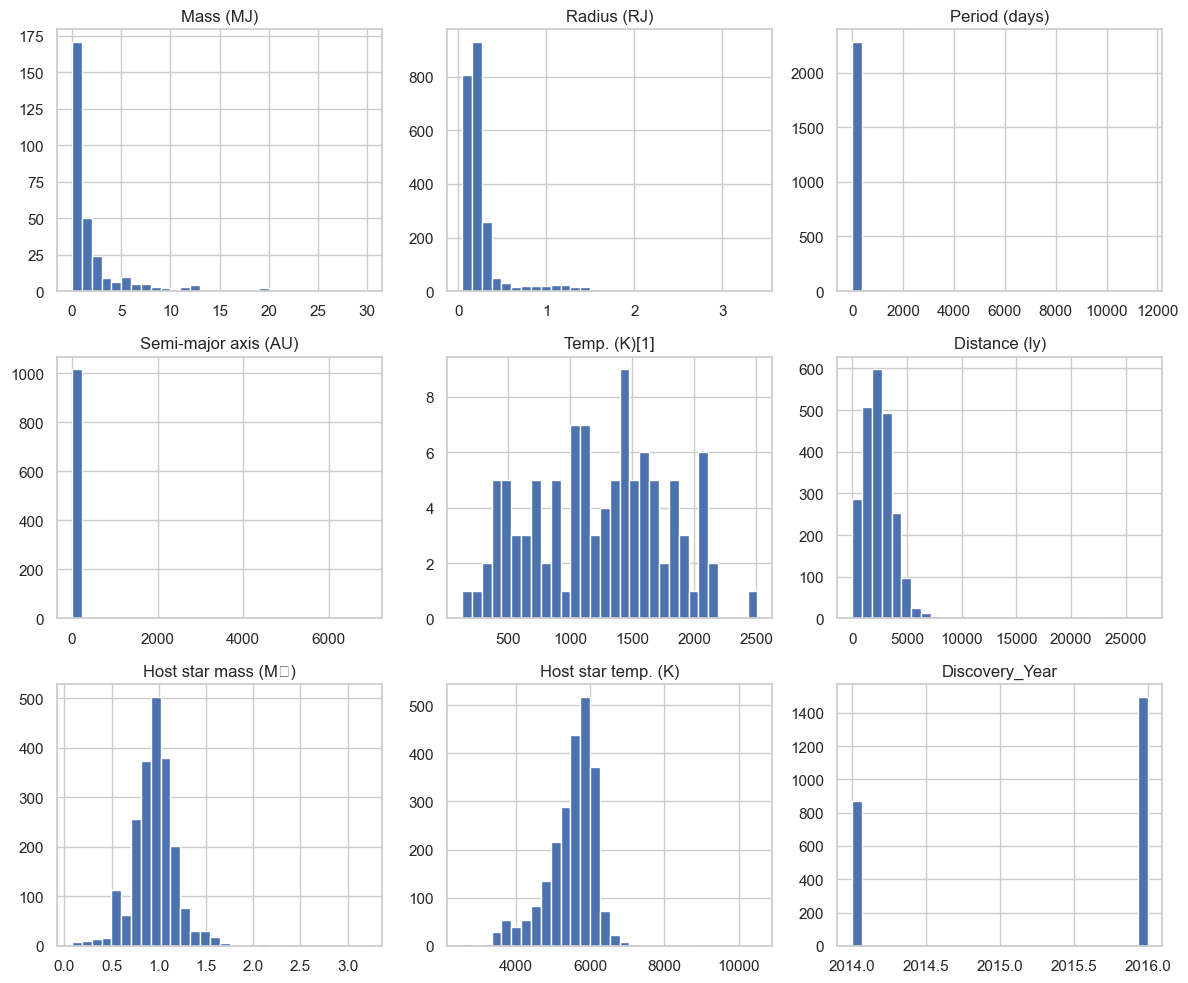

In [143]:


df = pd.read_csv('data_exoplanets.csv')
df.hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

bisa dilihat dari distribusinya, beberapa fitur hanya memiliki 1 batang saja dikarenakan outlier yang terlalu tinggi, jadi dari data ini kita bisa untuk menghapus outlier nantinya agar distribusi fitur kontinu ini bisa stabil

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18496\2374799409.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Discovery method", data=data, palette="Set2")


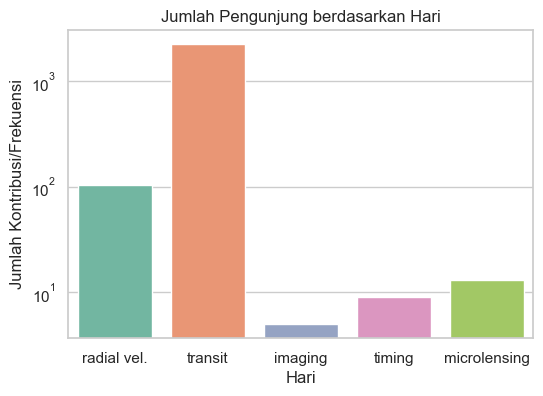

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Discovery method", data=data, palette="Set2")
plt.title("Discovery Method")
plt.xlabel("Hari")
plt.yscale("log")
plt.ylabel("Jumlah Kontribusi/Frekuensi")
plt.show()


dari sini kita bisa melihat bahwa kebanyakan pengamat exoplanet itu menggunakan metode transit dan radial untuk mencari planet planet, karena kedua metode ini adalah cara paling efektif, efisien, dan saling melengkapi untuk mendeteksi serta memastikan keberadaan planet di luar tata surya

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


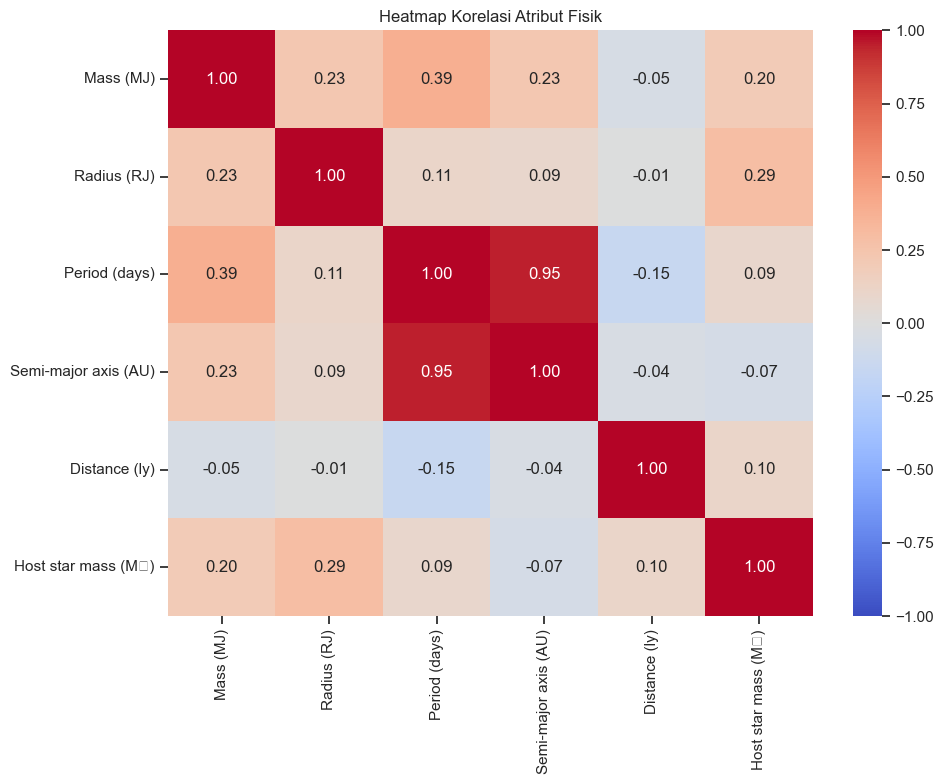

In [154]:
#heatmap

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Atribut Fisik')
plt.tight_layout()
plt.show()

1. Period (days) vs Semi-major axis (AU) (0,95): Korelasi positif sangat kuat. Semakin jauh jarak eksoplanet ke bintang induknya, semakin lama waktu yang dibutuhkan untuk menyelesaikan satu orbit. Hal ini sejalan dengan Hukum Kepler III.
2. Radius (RJ) vs Temp. (K) (0,80): Korelasi positif kuat. Planet dengan radius besar cenderung memiliki suhu yang lebih tinggi, mengindikasikan dominasi sampel eksoplanet tipe Hot Jupiters.
3. Host star mass (M☉) vs Host star temp. (K) (0,78): Korelasi positif kuat. Bintang induk yang lebih masif secara fisik menghasilkan suhu permukaan yang lebih panas.
4. Temp. (K) vs Host star mass (0,64) & Host star temp. (0,56): Korelasi positif sedang. Radiasi dari bintang yang lebih masif dan panas secara langsung meningkatkan suhu planet di sekitarnya.
5. Period (days) vs Temp. (K) (-0,32): Korelasi negatif sedang. Semakin jauh orbit planet dari bintangnya, suhunya cenderung semakin dingin.

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_18496\797857492.py:19: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  plt.savefig('bivariate_pairplot.png', dpi=300, bbox_inches='tight')
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9737 (\N{SUN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


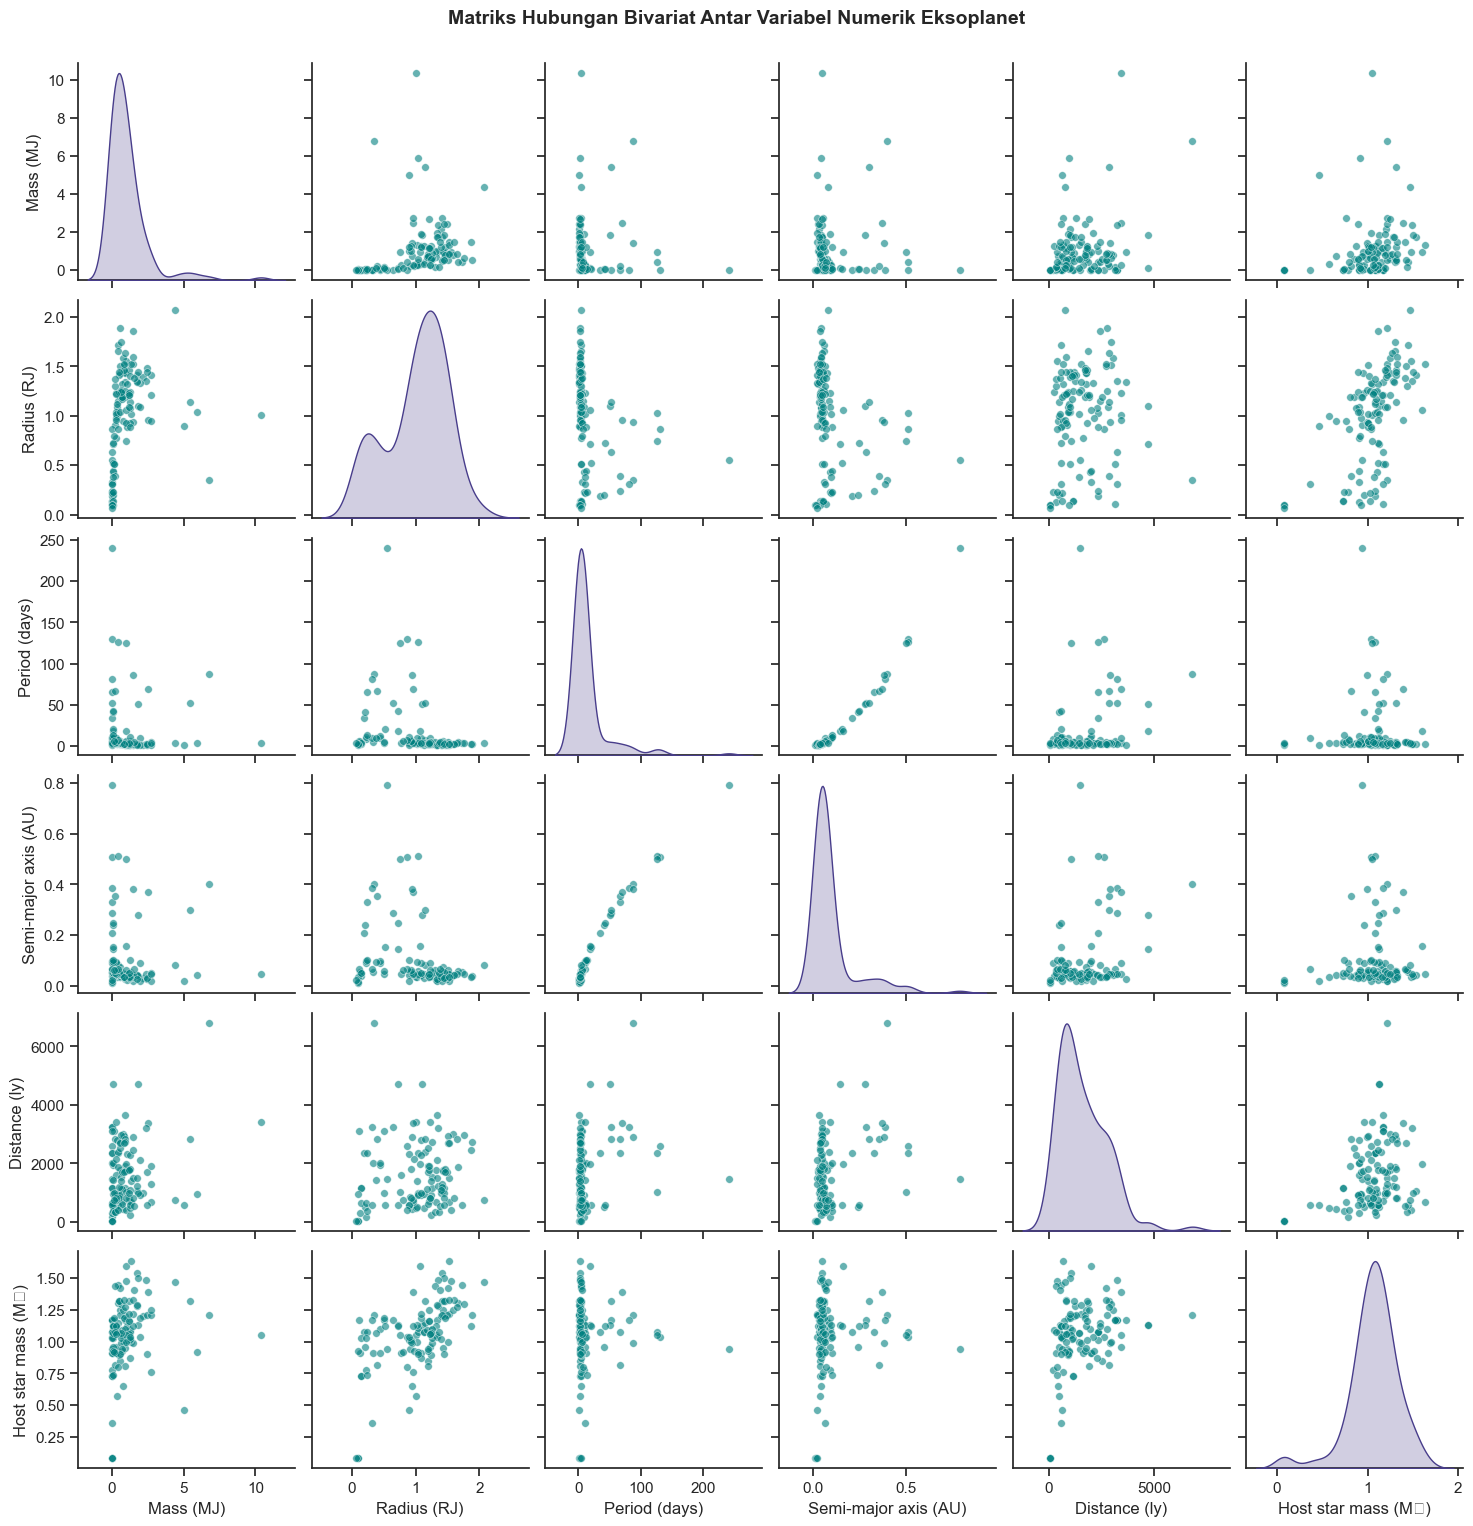

In [ ]:

sns.set_theme(style='ticks')
pair_plot = sns.pairplot(
    df[numeric_cols].dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'color': 'teal'},
    diag_kws={'color': 'darkslateblue'},
)

pair_plot.fig.suptitle(
    'Matriks Hubungan Bivariat Antar Variabel Numerik Eksoplanet',
    y=1.02,
    fontsize=14,
    fontweight='bold',
)

plt.show()